In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
print(tf.config.list_physical_devices())
print("GPUs:", tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
GPUs: []


E0000 00:00:1788456424.887185    5221 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1788456426.016073    5221 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [3]:
df = pd.read_csv("../data/electricity_load.csv")

print(df.head())
print(df.info())

           datetime  demand_kWh
0  01/01/2022 01:00        5.87
1  01/01/2022 02:00        5.95
2  01/01/2022 03:00        5.69
3  01/01/2022 04:00        6.05
4  01/01/2022 05:00        5.64
<class 'pandas.DataFrame'>
RangeIndex: 17519 entries, 0 to 17518
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    17519 non-null  str    
 1   demand_kWh  14675 non-null  float64
dtypes: float64(1), str(1)
memory usage: 273.9 KB
None


In [4]:
df["datetime"] = pd.to_datetime(
    df["datetime"],
    format="%d/%m/%Y %H:%M"
)

df = df.sort_values("datetime")

df = df.set_index("datetime")

df.head()

,demand_kWh
datetime,
2022-01-01 01:00:00,5.87
2022-01-01 02:00:00,5.95
2022-01-01 03:00:00,5.69
2022-01-01 04:00:00,6.05
2022-01-01 05:00:00,5.64


In [5]:
target = "demand_kWh"

series = df[[target]].copy()

# Make sure target is numeric
series[target] = pd.to_numeric(
    series[target],
    errors="coerce"
)

# Handle missing values
series[target] = series[target].interpolate(method="time")
series[target] = series[target].bfill().ffill()

print(series.head())
print("Missing values:", series[target].isna().sum())

                     demand_kWh
datetime                       
2022-01-01 01:00:00        5.87
2022-01-01 02:00:00        5.95
2022-01-01 03:00:00        5.69
2022-01-01 04:00:00        6.05
2022-01-01 05:00:00        5.64
Missing values: 0


In [6]:
# 80% training, 20% testing
train_size = int(len(series) * 0.80)

train = series.iloc[:train_size]
test = series.iloc[train_size:]

print("Total observations :", len(series))
print("Training observations:", len(train))
print("Testing observations :", len(test))

print("\nTraining period:")
print(train.index.min(), "to", train.index.max())

print("\nTesting period:")
print(test.index.min(), "to", test.index.max())

Total observations : 17519
Training observations: 14015
Testing observations : 3504

Training period:
2022-01-01 01:00:00 to 2023-08-07 23:00:00

Testing period:
2023-08-08 00:00:00 to 2023-12-31 23:00:00


In [7]:
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train)

test_scaled = scaler.transform(test)


In [8]:
lookback = 24       # previous 24 hours
forecast_horizon = 1


def create_sequences(data, lookback):
    X = []
    y = []

    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i])

    return np.array(X), np.array(y)


X_train, y_train = create_sequences(
    train_scaled,
    lookback
)

X_test, y_test = create_sequences(
    test_scaled,
    lookback
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


X_train shape: (13991, 24, 1)
y_train shape: (13991, 1)
X_test shape: (3480, 24, 1)
y_test shape: (3480, 1)


In [9]:
model = Sequential([
    Input(shape=(lookback, 1)),

    LSTM(64),

    Dense(32, activation="relu"),

    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0038 - mae: 0.0408 - val_loss: 0.0015 - val_mae: 0.0261
Epoch 2/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0020 - mae: 0.0271 - val_loss: 0.0012 - val_mae: 0.0221
Epoch 3/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0017 - mae: 0.0244 - val_loss: 0.0013 - val_mae: 0.0277
Epoch 4/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0016 - mae: 0.0234 - val_loss: 0.0010 - val_mae: 0.0205
Epoch 5/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0015 - mae: 0.0223 - val_loss: 9.6841e-04 - val_mae: 0.0185
Epoch 6/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0016 - mae: 0.0227 - val_loss: 9.8845e-04 - val_mae: 0.0183
Epoch 7/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0015 - mae: 0.0220 - val_loss: 9.4535e-04 - val_mae: 0.0189
Epoch 8/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0015 - mae: 0.0222 - val_loss: 9.5418e-04 - val_mae: 0.0190
Epoch 9/50
350/350 ━━━━━━━━━━━━━━━━━━━━ 

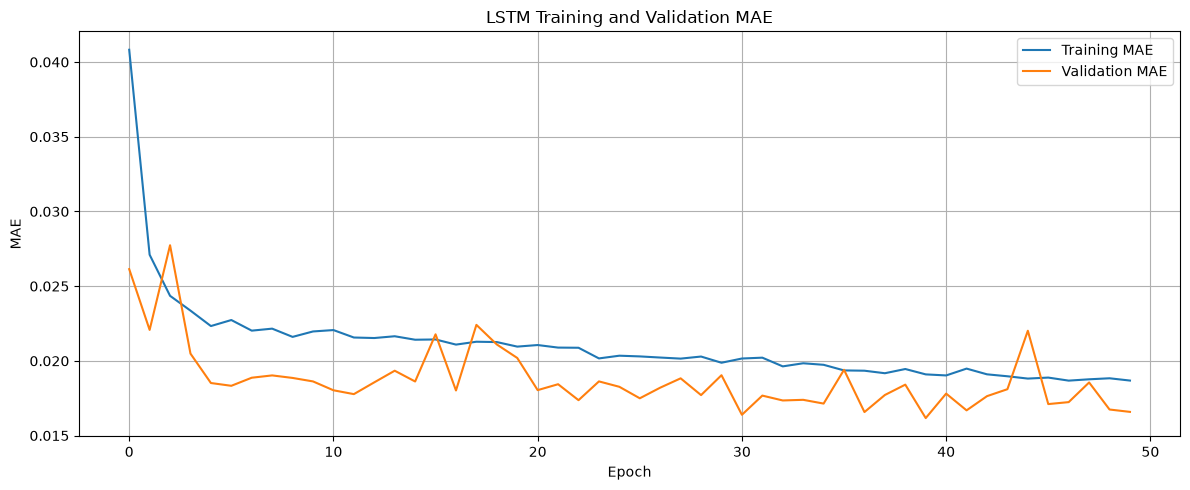

In [11]:

plt.figure(figsize=(12, 5))

plt.plot(
    history.history["mae"],
    label="Training MAE"
)

plt.plot(
    history.history["val_mae"],
    label="Validation MAE"
)

plt.title("LSTM Training and Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()


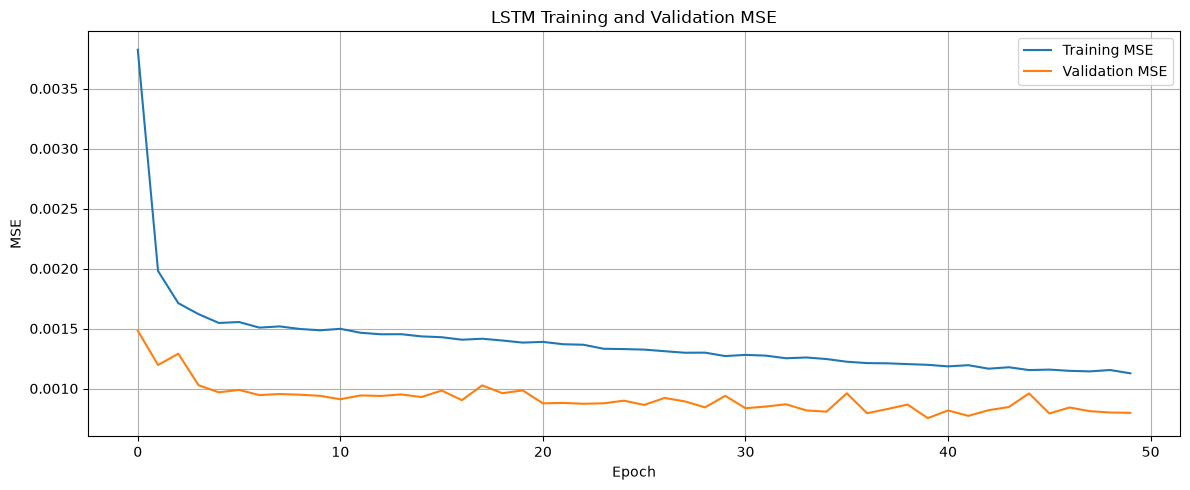

In [12]:
plt.figure(figsize=(12, 5))

plt.plot(
    history.history["loss"],
    label="Training MSE"
)

plt.plot(
    history.history["val_loss"],
    label="Validation MSE"
)

plt.title("LSTM Training and Validation MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

In [13]:
y_pred_scaled = model.predict(X_test)


109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [14]:
y_test_original = scaler.inverse_transform(
    y_test
)

y_pred_original = scaler.inverse_transform(
    y_pred_scaled
)



In [15]:
mae = mean_absolute_error(
    y_test_original,
    y_pred_original
)

mse = mean_squared_error(
    y_test_original,
    y_pred_original
)

rmse = np.sqrt(mse)

print("\nLSTM Evaluation Results")
print("=======================")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")


LSTM Evaluation Results
MAE  : 1.3810
MSE  : 6.2855
RMSE : 2.5071


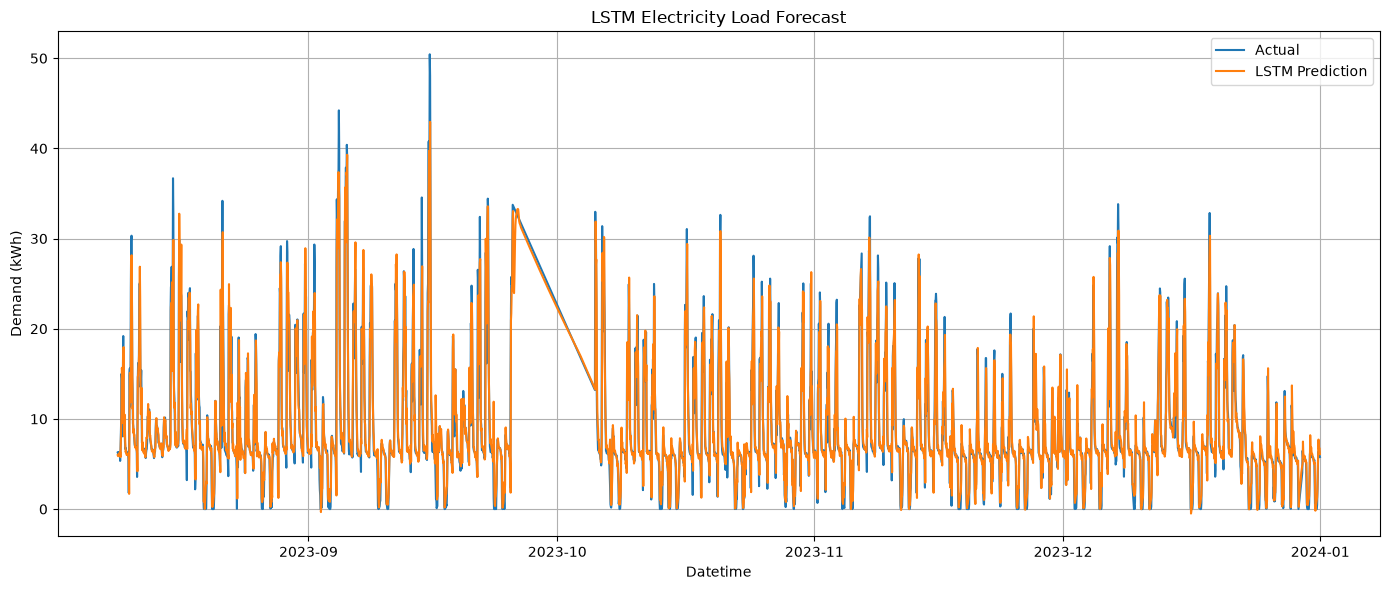

In [16]:
prediction_dates = test.index[lookback:]

plt.figure(figsize=(14, 6))

plt.plot(
    prediction_dates,
    y_test_original.flatten(),
    label="Actual"
)

plt.plot(
    prediction_dates,
    y_pred_original.flatten(),
    label="LSTM Prediction"
)

plt.title("LSTM Electricity Load Forecast")
plt.xlabel("Datetime")
plt.ylabel("Demand (kWh)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()